In [1]:
# Install requests (needed for API part)
!pip install requests

from datetime import datetime
import requests

# -------------------------------
# Create python_notes.txt
# -------------------------------

notes = [
    "Topic 1: Variables store data. Python is dynamically typed.",
    "Topic 2: Lists are ordered and mutable.",
    "Topic 3: Dictionaries store key-value pairs.",
    "Topic 4: Loops automate repetitive tasks.",
    "Topic 5: Exception handling prevents crashes."
]

# Write file
with open("python_notes.txt", "w", encoding="utf-8") as f:
    for line in notes:
        f.write(line + "\n")

print("File written successfully.")

# Append extra lines
with open("python_notes.txt", "a", encoding="utf-8") as f:
    f.write("Topic 6: Functions improve code reusability.\n")
    f.write("Topic 7: APIs allow communication between systems.\n")

print("Lines appended successfully.")

# -------------------------------
# Create error_log.txt
# -------------------------------

def log_error(function_name, message):
    with open("error_log.txt", "a", encoding="utf-8") as f:
        time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f"[{time}] ERROR in {function_name}: {message}\n")

# Trigger ConnectionError
try:
    requests.get("https://this-host-does-not-exist-xyz.com/api", timeout=5)
except Exception as e:
    print("Connection error triggered")
    log_error("fetch_products", "ConnectionError — No connection")

# Trigger HTTP error (404)
response = requests.get("https://dummyjson.com/products/999")

if response.status_code != 200:
    print("HTTP error triggered")
    log_error("lookup_product", "HTTPError — 404 Not Found for product ID 999")

# -------------------------------
# Display created files
# -------------------------------

print("\n--- python_notes.txt ---")
with open("python_notes.txt", "r", encoding="utf-8") as f:
    print(f.read())

print("\n--- error_log.txt ---")
with open("error_log.txt", "r", encoding="utf-8") as f:
    print(f.read())

File written successfully.
Lines appended successfully.
Connection error triggered
HTTP error triggered

--- python_notes.txt ---
Topic 1: Variables store data. Python is dynamically typed.
Topic 2: Lists are ordered and mutable.
Topic 3: Dictionaries store key-value pairs.
Topic 4: Loops automate repetitive tasks.
Topic 5: Exception handling prevents crashes.
Topic 6: Functions improve code reusability.
Topic 7: APIs allow communication between systems.


--- error_log.txt ---
[2026-03-26 18:58:46] ERROR in fetch_products: ConnectionError — No connection
[2026-03-26 18:58:46] ERROR in lookup_product: HTTPError — 404 Not Found for product ID 999



First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary stats:
             math    science    english    his

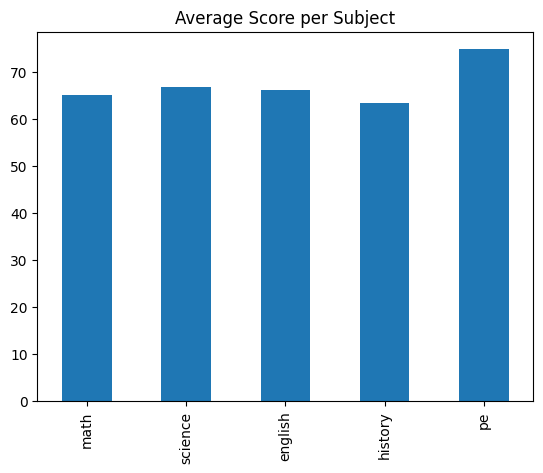

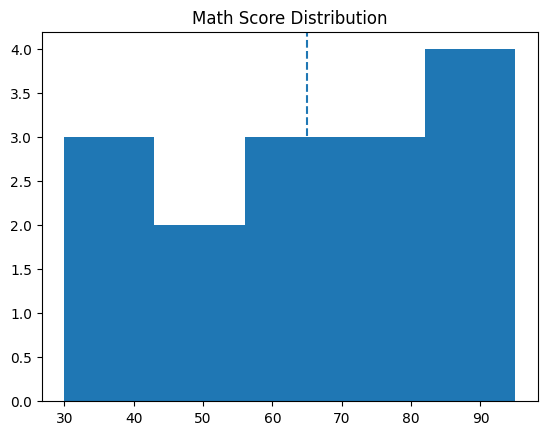

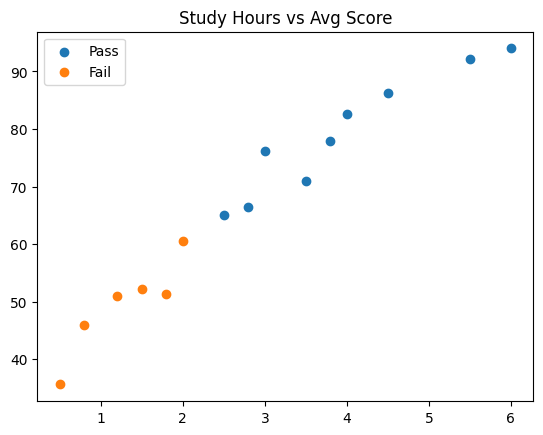

/tmp/ipykernel_7863/2354858174.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])


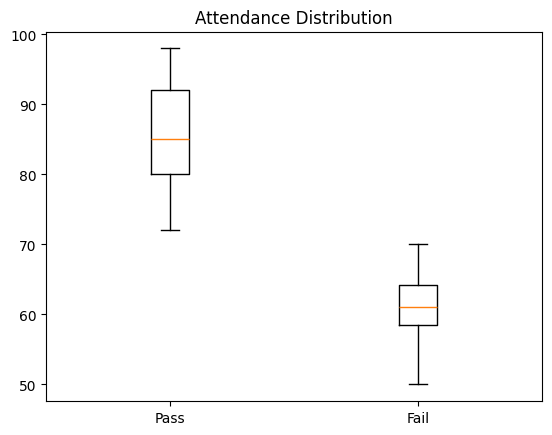

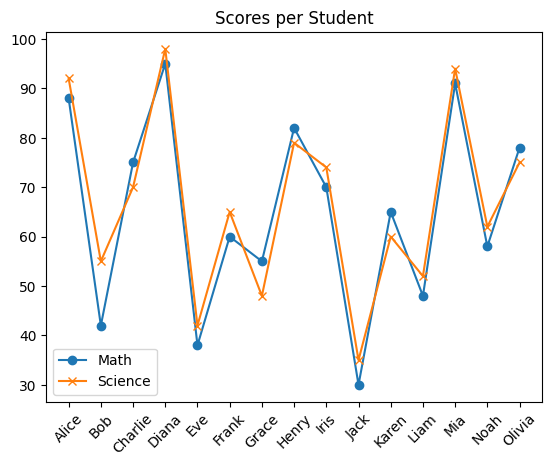

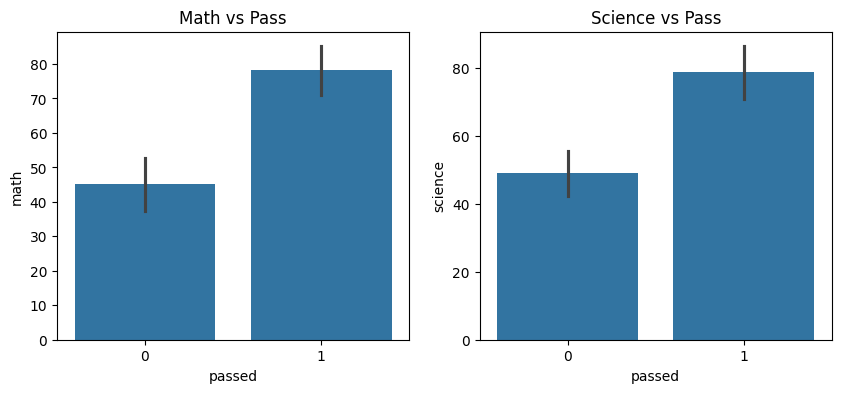

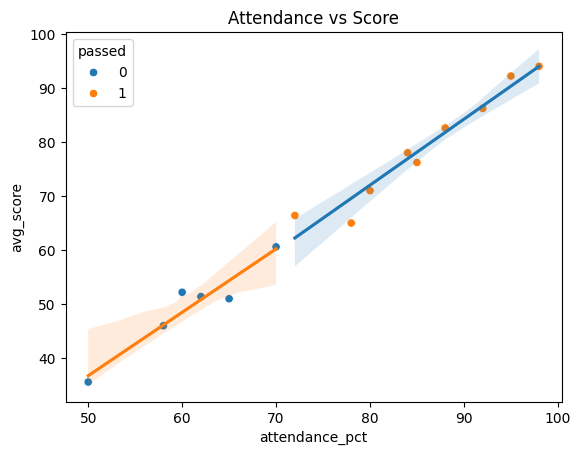


Training accuracy: 1.0
Test accuracy: 1.0
Jack 0 0
Liam 0 0
Alice 1 1


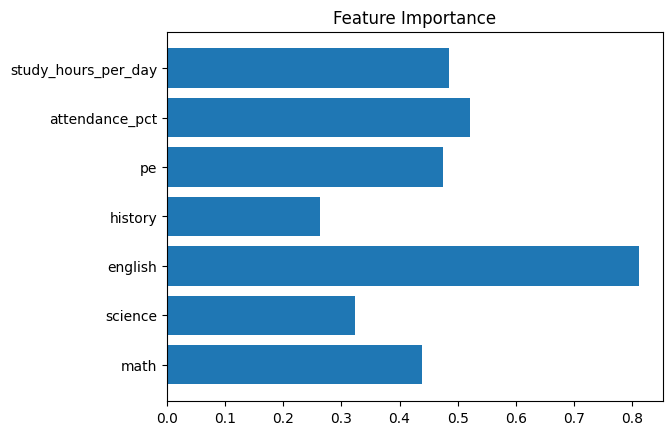


New Student Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# Install libraries
!pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())

print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)

print("\nSummary stats:\n", df.describe())

print("\nPass/Fail count:")
print(df['passed'].value_counts())

# Subject columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores (Pass):")
print(df[df['passed']==1][subject_cols].mean())

print("\nAverage scores (Fail):")
print(df[df['passed']==0][subject_cols].mean())

# Highest average student
df['avg_all'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_all'].idxmax()]
print("\nTop Student:", top_student['name'])

# =========================================================
# Task 2 — Matplotlib
# =========================================================

df['avg_score'] = df[subject_cols].mean(axis=1)

# Bar chart
plt.figure()
df[subject_cols].mean().plot(kind='bar')
plt.title("Average Score per Subject")
plt.savefig("plot1_bar.png")
plt.show()

# Histogram
plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Score Distribution")
plt.savefig("plot2_hist.png")
plt.show()

# Scatter
plt.figure()
plt.scatter(df[df['passed']==1]['study_hours_per_day'], df[df['passed']==1]['avg_score'], label='Pass')
plt.scatter(df[df['passed']==0]['study_hours_per_day'], df[df['passed']==0]['avg_score'], label='Fail')
plt.legend()
plt.title("Study Hours vs Avg Score")
plt.savefig("plot3_scatter.png")
plt.show()

# Boxplot
plt.figure()
pass_att = df[df['passed']==1]['attendance_pct']
fail_att = df[df['passed']==0]['attendance_pct']
plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])
plt.title("Attendance Distribution")
plt.savefig("plot4_box.png")
plt.show()

# Line plot
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')
plt.xticks(rotation=45)
plt.legend()
plt.title("Scores per Student")
plt.savefig("plot5_line.png")
plt.show()

# =========================================================
# Task 3 — Seaborn
# =========================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math vs Pass")

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science vs Pass")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

plt.figure()
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False)
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False)

plt.title("Attendance vs Score")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# =========================================================
# Task 4 — Machine Learning
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("\nTraining accuracy:", model.score(X_train_scaled,y_train))
print("Test accuracy:", model.score(X_test_scaled,y_test))

pred = model.predict(X_test_scaled)

for i, idx in enumerate(X_test.index):
    name = df.loc[idx,'name']
    actual = y_test.iloc[i]
    predicted = pred[i]
    print(name, actual, predicted)

# Feature importance
coeff = model.coef_[0]
features = X.columns

plt.figure()
plt.barh(features, coeff)
plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

# New student prediction
new_student = [[75,70,68,65,80,82,3.2]]
new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("\nNew Student Prediction:", "Pass" if prediction[0]==1 else "Fail")
print("Probability:", prob)